In [1]:
#This part of the code loads our training data,
#extracts the images and their matching labels
#uses the extracted data to train a model
#saves the model and plots the metrics/loss over the epochs


import cv2
import re
import os
import csv
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

from data_processing.data_encoder import DataEncoder
%matplotlib inline

from config_loader import Config
from data_processing.data_encoder import DataEncoder
from cnn.CustomMetric import CustomMetric
from cnn.custom_loss import custom_loss
from cnn.model_mobilenetv2 import build_model

from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TerminateOnNaN, CSVLogger

In [2]:
# import config
nb_conf = Config('config.json')

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Available GPU\'s:")
tf.config.list_physical_devices('GPU')

Num GPUs Available:  1
Available GPU's:


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
# import data encoder
encoder = DataEncoder(nb_conf)
data_dir = nb_conf.generator.train_data_dir
label_dir = Path(nb_conf.generator.train_labels_dir) / nb_conf.generator.train_label_file
X, y, ref_coords, ref_center = encoder(data_dir, label_dir)

print("Reference points: ", ref_coords, ref_coords.shape)
print("Reference center: ", ref_center, ref_center.shape)

Input encoded...
Input values normalized...
Shape:  (10, 256, 256, 3)  Type:  <class 'numpy.ndarray'>  dtype:  float64
Labels generated from:  datasets/training/training.csv
Labels normalized...
Shape:  (10, 8)  Type:  <class 'numpy.ndarray'>  dtype:  float64
Reference points:  [0.27734375 0.27734375 0.72265625 0.27734375 0.27734375 0.71875
 0.72265625 0.71875   ] (8,)
Reference center:  [0.5 0.5] (2,)


In [4]:
input_shape = X.shape[1:]
output_shape = y.shape[1]

metric = CustomMetric(ref_center, ref_coords, nb_conf)
model = build_model(input_shape, output_shape)

2024-11-16 14:26:38.334553: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2024-11-16 14:26:38.334598: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-11-16 14:26:38.334609: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-11-16 14:26:38.334627: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-11-16 14:26:38.334646: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/keremaras/Projects/aoi-pcb-v1/cnn/model_mobilenetv2.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for inpu

In [5]:
#model = get_model()
model.summary()

Model: "keypoint_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 1280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 4, 4, 8)        │        42,248 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,370,384 (9.04 MB)

 Trainable params: 112,400 (439.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
#custom metrics not yet implemented
model.compile(optimizer=nb_conf.training.optimizer, 
              loss=custom_loss,
              metrics=[metric.custom_metric])

In [7]:
os.chdir(os.path.join(models_dir, "Model_Logs"))
csv_logger = CSVLogger(filename='cl_cm_test_logs.csv',
                       separator=',',
                       append=True)

early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=0.0,
                               patience=30,
                               verbose=1,
                               restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.001)

callbacks = [csv_logger,
             reduce_lr]

NameError: name 'models_dir' is not defined

In [10]:
history = model.fit(X, y, validation_split=0.3, epochs=3000, verbose=1)

Epoch 1/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - custom_metric: 0.1168 - loss: 0.0045 - val_custom_metric: 0.0904 - val_loss: 5.9745e-04
Epoch 2/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - custom_metric: 0.0988 - loss: 0.0049 - val_custom_metric: 0.0910 - val_loss: 5.6558e-04
Epoch 3/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - custom_metric: 0.0849 - loss: 0.0069 - val_custom_metric: 0.0944 - val_loss: 5.2237e-04
Epoch 4/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - custom_metric: 0.1079 - loss: 0.0032 - val_custom_metric: 0.0977 - val_loss: 5.1215e-04
Epoch 5/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - custom_metric: 0.1154 - loss: 0.0054 - val_custom_metric: 0.0993 - val_loss: 4.6855e-04
Epoch 6/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - custom_metric: 0.1310 - loss: 0.0047 - val_custom_metric: 0.1002 - val_loss: 5.1596e-04
Epoch 7/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - custom_metric: 0.0685 - loss: 0.0036 - val_custom_metric: 0.1056 - val_loss: 6.3630e-04
Epoch 8/3000

KeyboardInterrupt: 

In [19]:
os.chdir(models_dir)
model.save("cl_cm_test_model")

INFO:tensorflow:Assets written to: cl_cm_test_model/assets


In [20]:
#list all data in history
print(history.history.keys())

dict_keys(['loss', 'custom_metric', 'val_loss', 'val_custom_metric', 'lr'])


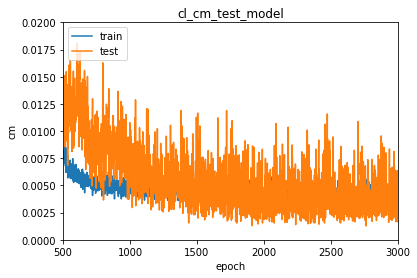

In [26]:
# summarize history for accuracy
plt.plot(history.history['custom_metric'])
plt.plot(history.history['val_custom_metric'])
plt.title('cl_cm_test_model')
plt.ylabel('cm')
plt.xlabel('epoch')
plt.xlim(500, 3000)
plt.ylim(0, 0.02)
plt.legend(['train', 'test'], loc='upper left')
plt.show()

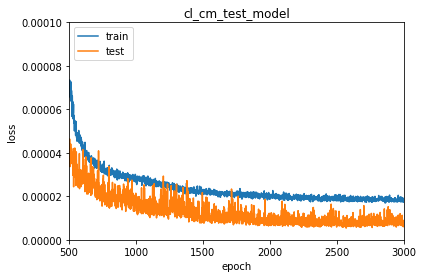

In [29]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('cl_cm_test_model')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.xlim(500, 3000)
plt.ylim(0, 0.0001)
plt.show()